In [41]:
import numpy   as np
import pandas  as pd
import seaborn as sns

import plotly.express as px
import matplotlib.pyplot as plt

In [42]:
import matplotlib.pyplot as plt

In [43]:
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.multicomp     import pairwise_tukeyhsd

In [44]:
import scipy.stats as stats

In [45]:
df_community_0 = pd.read_csv("../data/communities/by_color/df_community_0.csv")
df_community_1 = pd.read_csv("../data/communities/by_color/df_community_1.csv")
df_community_2 = pd.read_csv("../data/communities/by_color/df_community_2.csv")
df_community_3 = pd.read_csv("../data/communities/by_color/df_community_3.csv")
df_community_4 = pd.read_csv("../data/communities/by_color/df_community_4.csv")
df_community_5 = pd.read_csv("../data/communities/by_color/df_community_5.csv")
df_community_6 = pd.read_csv("../data/communities/by_color/df_community_6.csv")
df_community_7 = pd.read_csv("../data/communities/by_color/df_community_7.csv")

In [46]:
dfs = [
    df_community_0, df_community_1, df_community_2, df_community_3, 
    df_community_4, df_community_5, df_community_6, df_community_7
]

df_all = pd.concat(dfs)

In [47]:
# Colores optivos y UV (Emision del disco)
df_all['u_g'] = df_all['M_u'] - df_all['M_g']
df_all['g_r'] = df_all['M_g'] - df_all['M_r']
df_all['r_i'] = df_all['M_r'] - df_all['M_i']
df_all['i_z'] = df_all['M_i'] - df_all['M_z']
df_all['FUV_NUV'] = df_all['M_FUV'] - df_all['M_NUV']

# Colores Infrarrojos (Emisión térmica del polvo/toroide)
df_all['j_h'] = df_all['M_2j'] - df_all['M_2h']
df_all['h_k'] = df_all['M_2h'] - df_all['M_2k']
df_all['W1_W2'] = df_all['M_W1'] - df_all['M_W2']

# Cruces espectrales (Relación óptica-infrarroja)
df_all['i_W1'] = df_all['M_i'] - df_all['M_W1']
df_all['r_W2'] = df_all['M_r'] - df_all['M_W2']

# Big Blue Bump
df_all["NUV_u"] = df_all["M_NUV"] - df_all["M_u"]
df_all["NUV_g"] = df_all["M_NUV"] - df_all["M_g"]

In [48]:
formula = 'u_g + g_r + r_i + i_z + FUV_NUV + j_h + h_k + W1_W2 + i_W1 + r_W2 + NUV_u + NUV_g + M_r ~ C(community)'

In [49]:
print("Calculando MANOVA... (esto puede tardar unos segundos dependiendo del tamaño del dataset)")
manova = MANOVA.from_formula(formula, data=df_all)
resultados = manova.mv_test()

# 6. Imprimimos el resumen
print(resultados)

Calculando MANOVA... (esto puede tardar unos segundos dependiendo del tamaño del dataset)
                     Multivariate linear model
                                                                    
--------------------------------------------------------------------
       Intercept         Value    Num DF   Den DF   F Value   Pr > F
--------------------------------------------------------------------
          Wilks' lambda   0.0065 11.0000 5753.0000 79501.9312 0.0000
         Pillai's trace   0.9935 11.0000 5753.0000 79501.9312 0.0000
 Hotelling-Lawley trace 152.0113 11.0000 5753.0000 79501.9312 0.0000
    Roy's greatest root 152.0113 11.0000 5753.0000 79501.9312 0.0000
--------------------------------------------------------------------
                                                                    
--------------------------------------------------------------------
        C(community)      Value   Num DF   Den DF    F Value  Pr > F
-----------------------------------

In [50]:
# Lista de las características (colores) que vamos a evaluar
features = [
    'u_g', 'g_r', 'r_i', 'i_z', 'FUV_NUV', 
    'j_h', 'h_k', 'W1_W2', 'i_W1', 'r_W2',
    'NUV_u', 'NUV_g', 'M_r'
]

# Lista para almacenar los resultados
anova_results = []

# Iteramos sobre cada feature para hacer un ANOVA individual
for feature in features:
    # Agrupamos los datos del feature actual por comunidad
    # Asegúrate de usar df_clean (sin NaNs) del paso anterior
    grupos = [grupo[feature].values for nombre, grupo in df_all.groupby('community')]
    
    # Ejecutamos el ANOVA
    f_stat, p_value = stats.f_oneway(*grupos)
    
    # Guardamos los resultados
    anova_results.append({
        'Característica': feature,
        'Estadístico F': f_stat,
        'Valor p': p_value,
        'Significativo (p < 0.05)': p_value < 0.05
    })

# Convertimos los resultados en un DataFrame para una visualización limpia
df_resultados_anova = pd.DataFrame(anova_results)

# Mostramos la tabla
print(df_resultados_anova.to_string(index=False))

Característica  Estadístico F       Valor p  Significativo (p < 0.05)
           u_g     345.070557  0.000000e+00                      True
           g_r     449.090401  0.000000e+00                      True
           r_i     238.447023 1.599719e-312                      True
           i_z     460.155274  0.000000e+00                      True
       FUV_NUV    1265.573672  0.000000e+00                      True
           j_h     314.443045  0.000000e+00                      True
           h_k     276.605997  0.000000e+00                      True
         W1_W2     534.641511  0.000000e+00                      True
          i_W1     623.344052  0.000000e+00                      True
          r_W2     619.033046  0.000000e+00                      True
         NUV_u    1827.022455  0.000000e+00                      True
         NUV_g    1733.689683  0.000000e+00                      True
           M_r     826.001662  0.000000e+00                      True


In [51]:
# Lista de todos tus features, incluyendo los nuevos
features = ['u_g', 'g_r', 'r_i', 'i_z', 'FUV_NUV', 'j_h', 'h_k', 
            'W1_W2', 'i_W1', 'r_W2', 'NUV_u', 'NUV_g', 'M_r']

print("Jerarquía de Comunidades por Feature (Orden de mayor a menor)\n" + "="*80)

for feature in features:
    # 1. Calculamos la media y la desviación estándar, ordenando por la media descendente
    stats_df = df_all.groupby('community')[feature].agg(['mean', 'std']).sort_values(by='mean', ascending=False)
    comunidades_ordenadas = stats_df.index.tolist()
    
    # 2. Corremos el test de Tukey para identificar empates estadísticos
    tukey = pairwise_tukeyhsd(endog=df_all[feature], groups=df_all['community'], alpha=0.05)
    
    # 3. Extraemos los resultados de Tukey a un diccionario para consultas rápidas
    resultados_tukey = {}
    for i, fila in enumerate(tukey._results_table.data):
        if i == 0: 
            continue # Saltamos el encabezado de la tabla
        grupo1, grupo2, reject = fila[0], fila[1], fila[6]
        # Guardamos ambas direcciones para la búsqueda
        resultados_tukey[f"{grupo1}-{grupo2}"] = reject
        resultados_tukey[f"{grupo2}-{grupo1}"] = reject

    # 4. Construimos la jerarquía de texto con los valores estadísticos
    jerarquia = ""
    
    for i in range(len(comunidades_ordenadas)):
        com_actual = comunidades_ordenadas[i]
        media = stats_df.loc[com_actual, 'mean']
        desviacion = stats_df.loc[com_actual, 'std']
        
        # Formateamos la comunidad con sus valores (usamos 2 decimales para limpieza visual)
        jerarquia += f"{com_actual}(mean:{media:.2f},std:{desviacion:.2f})"
        
        # Determinamos el conector si no estamos en la última comunidad
        if i < len(comunidades_ordenadas) - 1:
            com_siguiente = comunidades_ordenadas[i+1]
            son_diferentes = resultados_tukey.get(f"{com_actual}-{com_siguiente}", True)
            
            if son_diferentes:
                jerarquia += " > "
            else:
                jerarquia += " ≈ "
            
    # 5. Imprimimos el resultado formateado
    print(f"{feature}:\n  {jerarquia}\n")

Jerarquía de Comunidades por Feature (Orden de mayor a menor)
u_g:
  6(mean:0.58,std:0.31) > 5(mean:0.25,std:0.15) ≈ 7(mean:0.25,std:0.16) ≈ 1(mean:0.23,std:0.11) ≈ 0(mean:0.22,std:0.21) ≈ 3(mean:0.20,std:0.12) ≈ 2(mean:0.20,std:0.18) ≈ 4(mean:0.17,std:0.11)

g_r:
  6(mean:0.60,std:0.20) > 0(mean:0.44,std:0.15) > 5(mean:0.40,std:0.12) > 7(mean:0.37,std:0.09) > 1(mean:0.35,std:0.08) ≈ 4(mean:0.34,std:0.09) > 2(mean:0.31,std:0.11) ≈ 3(mean:0.30,std:0.11)

r_i:
  6(mean:0.27,std:0.11) > 0(mean:0.19,std:0.10) > 3(mean:0.17,std:0.09) ≈ 1(mean:0.15,std:0.06) ≈ 7(mean:0.15,std:0.06) ≈ 5(mean:0.14,std:0.08) ≈ 4(mean:0.13,std:0.07) > 2(mean:0.08,std:0.13)

i_z:
  6(mean:0.29,std:0.11) > 0(mean:0.26,std:0.09) ≈ 7(mean:0.25,std:0.06) > 1(mean:0.23,std:0.07) ≈ 5(mean:0.22,std:0.08) ≈ 2(mean:0.22,std:0.11) > 4(mean:0.18,std:0.08) > 3(mean:-0.01,std:0.11)

FUV_NUV:
  7(mean:5.34,std:1.70) > 6(mean:1.82,std:1.40) > 1(mean:1.65,std:0.90) > 5(mean:1.45,std:1.13) > 4(mean:1.07,std:0.85) ≈ 0(mean:0.89,st

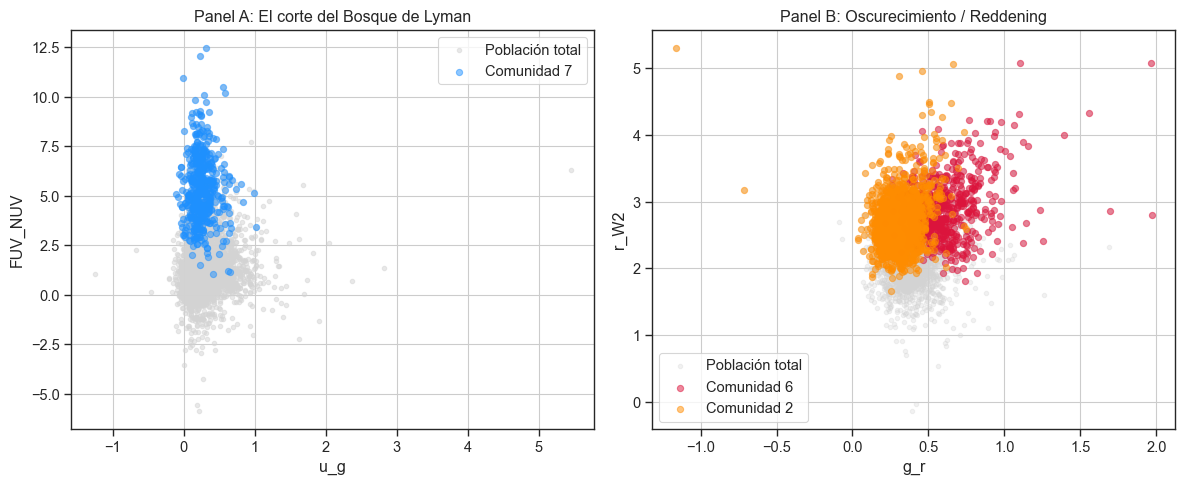

In [59]:
# Configuración de estilo general para que luzca como de paper
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# Crear la figura con 1 fila y 2 columnas (Panel A y B)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Panel A: FUV_NUV vs u_g (El corte del Bosque de Lyman) ---
# Población de fondo en gris
axes[0].scatter(df_all['u_g'], df_all['FUV_NUV'], 
                color='lightgrey', alpha=0.5, s=10, label='Población total', zorder=1)
# Comunidad 7 destacada
c7_data = df_all[df_all['community'] == 7]
axes[0].scatter(c7_data['u_g'], c7_data['FUV_NUV'], 
                color='dodgerblue', alpha=0.5, s=20, label='Comunidad 7', zorder=2)

axes[0].set_xlabel('u_g')
axes[0].set_ylabel('FUV_NUV')
axes[0].legend(loc='best')
axes[0].set_title('Panel A: El corte del Bosque de Lyman')
axes[0].grid()

# --- Panel B: r_W2 vs g_r (El oscurecimiento) ---
# Población de fondo en gris
axes[1].scatter(df_all['g_r'], df_all['r_W2'], 
                color='lightgrey', alpha=0.3, s=10, label='Población total', zorder=1)
# Comunidades 6 y 2 destacadas
c6_data = df_all[df_all['community'] == 6]
c2_data = df_all[df_all['community'] == 2]
axes[1].scatter(c6_data['g_r'], c6_data['r_W2'], 
                color='crimson', alpha=0.5, s=20, label='Comunidad 6', zorder=2)
axes[1].scatter(c2_data['g_r'], c2_data['r_W2'], 
                color='darkorange', alpha=0.5, s=20, label='Comunidad 2', zorder=3)

axes[1].set_xlabel('g_r')
axes[1].set_ylabel('r_W2')
axes[1].legend(loc='best')
axes[1].set_title('Panel B: Oscurecimiento / Reddening')
axes[1].grid()

plt.tight_layout()
plt.show()

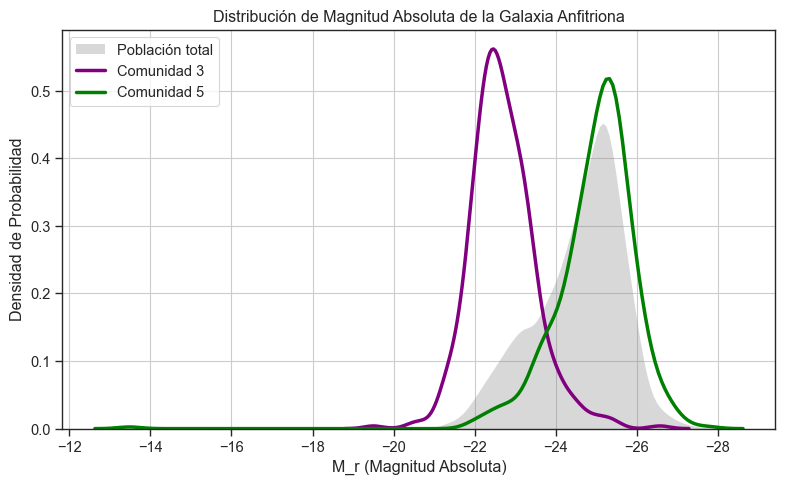

In [60]:
plt.figure(figsize=(8, 5))

# Fondo: Curva suave de la población total (rellena)
sns.kdeplot(data=df_all, x='M_r', color='grey', fill=True, alpha=0.3, 
            label='Población total', linewidth=0)

# Curvas de las comunidades de interés (sin relleno para ver los cruces)
sns.kdeplot(data=df_all[df_all['community'] == 3], x='M_r', 
            color='purple', linewidth=2.5, label='Comunidad 3')
sns.kdeplot(data=df_all[df_all['community'] == 5], x='M_r', 
            color='green', linewidth=2.5, label='Comunidad 5')

# Invertimos el eje X si es magnitud absoluta (valores más negativos son más brillantes)
plt.gca().invert_xaxis()

plt.xlabel('M_r (Magnitud Absoluta)')
plt.ylabel('Densidad de Probabilidad')
plt.title('Distribución de Magnitud Absoluta de la Galaxia Anfitriona')
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid()
plt.show()

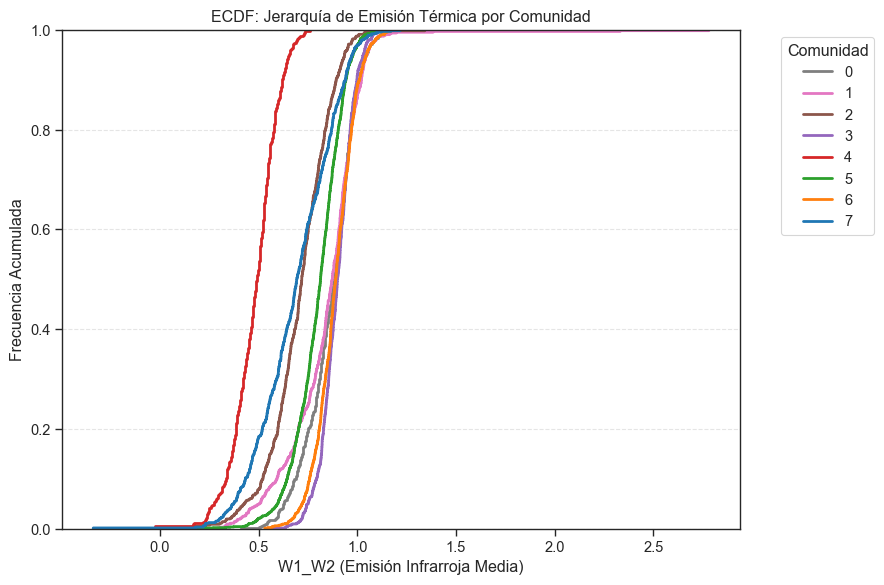

In [54]:
plt.figure(figsize=(9, 6))

# Usamos la paleta 'tab10' que tiene colores bien contrastados para 8 a 10 categorías
# ECDFplot traza automáticamente las proporciones acumuladas
sns.ecdfplot(data=df_all, x='W1_W2', hue='community', palette='tab10', linewidth=2)

plt.xlabel('W1_W2 (Emisión Infrarroja Media)')
plt.ylabel('Frecuencia Acumulada')
plt.title('ECDF: Jerarquía de Emisión Térmica por Comunidad')

# Movemos la leyenda fuera del gráfico para que no tape las curvas
plt.legend(title='Comunidad', 
           labels=sorted(df_all['community'].unique()), 
           bbox_to_anchor=(1.05, 1), loc='upper left')

# Opcional: añadir una cuadrícula sutil para facilitar la lectura del eje Y
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

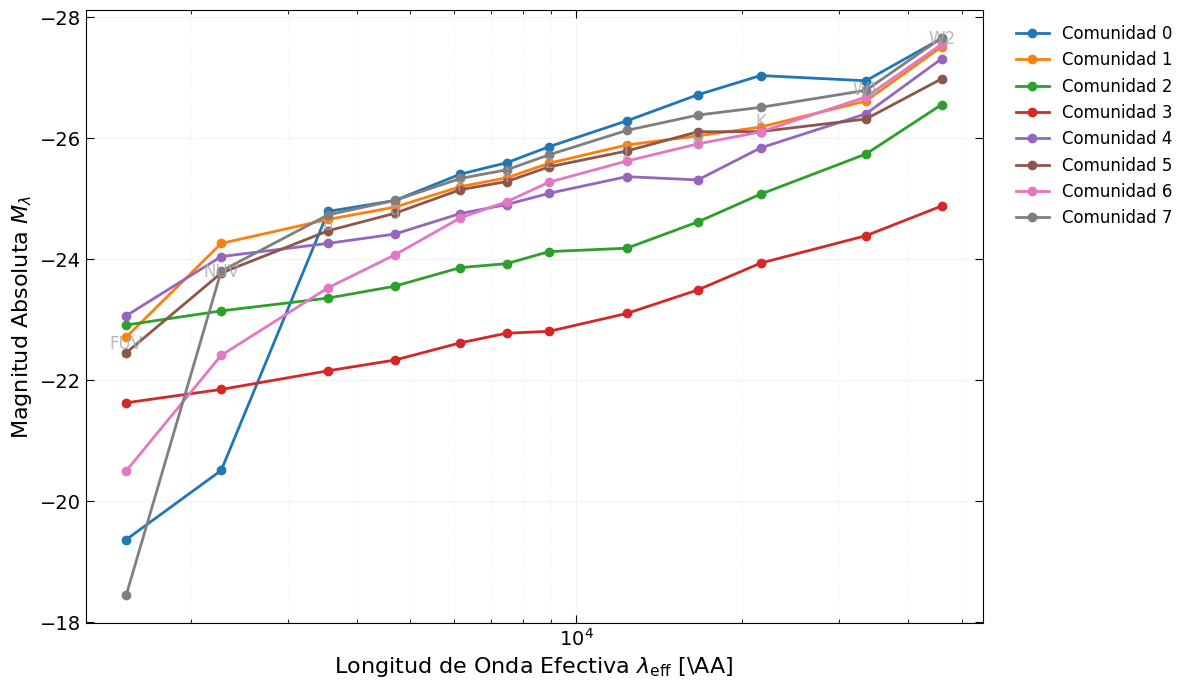

In [55]:
plt.style.use('default')

wavelengths = {
    'M_FUV': 1528, 'M_NUV': 2271, 
    'M_u': 3551, 'M_g': 4686, 'M_r': 6165, 'M_i': 7481, 'M_z': 8931,
    'M_2j': 12350, 'M_2h': 16620, 'M_2k': 21590, 
    'M_W1': 33526, 'M_W2': 46028
}

band_names = ['FUV', 'NUV', 'u', 'g', 'r', 'i', 'z', 'J', 'H', 'K', 'W1', 'W2']
cols_mags = list(wavelengths.keys())
waves = list(wavelengths.values())

fig, ax = plt.subplots(figsize=(12, 7))

# Iteramos directamente sobre las comunidades del dataframe limpio
for comunidad, df_grupo in df_all.groupby('community'):
    medias = df_grupo[cols_mags].median()
    
    ax.plot(waves, medias, marker='o', linestyle='-', 
            linewidth=2, markersize=6, label=f'Comunidad {comunidad}')

ax.invert_yaxis()
ax.set_xscale('log')

ax.set_xlabel(r'Longitud de Onda Efectiva $\lambda_{\rm eff}$ [\AA]', fontsize=16)
ax.set_ylabel(r'Magnitud Absoluta $M_{\lambda}$', fontsize=16)

# Añadir nombres de filtros solo una vez (usando la mediana de la población general como referencia de altura)
medias_globales = df_all[cols_mags].median()
for w, m, name in zip(waves, medias_globales, band_names):
    ax.annotate(name, (w, m), textcoords="offset points", xytext=(0, 15), 
                ha='center', fontsize=12, color='darkgray', alpha=0.8)

ax.tick_params(axis='both', which='major', labelsize=14, direction='in', top=True, right=True, length=6)
ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True, length=3)

ax.grid(True, which="major", ls="-", alpha=0.15)
ax.grid(True, which="minor", ls=":", alpha=0.15)

# Leyenda fuera del gráfico para evitar tapar las curvas UV
ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)

plt.tight_layout()
plt.savefig('../results/figures/sed_fotometrica_comparativa.pdf', bbox_inches='tight', dpi=300)
plt.show()